# Autonomous Systems Portofolio - Blackjack
Groep 1: Maaike, Matthias, Tiziano, Willem

## Voorbereiding

In deze library gymnasium staat de environment van het blackjack spel, verder gebruiken we drie andere libraries om de resultaten netjes te visualiseren en op te slaan.

In [ ]:
# Blackjack environment
import gymnasium as gym
import sys

# Opslaan en exporteren van de resultaten
import matplotlib.pyplot as plt
import pandas as pd
import os

# Importeer de Agents
try:
    from agents.baseline_agent import baseline_policy
    from agents.hard_total_agent import hard_total_policy
    from agents.soft_total_agent import soft_total_policy
    from agents.dealer_aware_agent import dealer_aware_policy
    from agents.pro_bja_agent import bja_policy
    from agents.safe_play_agent import safe_play_policy
    from agents.probabilistic_agent import probabilistic_policy
    from agents.dealer_copy_agent import dealer_copy_policy

# Als er iets fout gaat met het ophalen van de agents stoppen we de simulatie.
except ImportError as e:
    print("\nFoutmelding: Een agent-bestand kon niet worden geladen.")
    print(f"Controleer of de bestandsnamen kloppen en in de 'agents' map staan.")
    print(f"Details: {e}")
    sys.exit()

In [ ]:
def run_simulation(policy_func, name, num_episodes=10000):
    """Runt de simulatie voor een specifieke agent in de Gymnasium omgeving."""

    # We gebruiken de officiële Gymnasium Blackjack omgeving
    env = gym.make("Blackjack-v1")
    results = []
    cumulative_profit = 0
    history = []

    for _ in range(num_episodes):
        obs, info = env.reset()
        terminated = False
        truncated = False
        
        while not (terminated or truncated):
            action = policy_func(obs)

            # Voer de actie uit (0 = Stand, 1 = Hit)
            obs, reward, terminated, truncated, info = env.step(action)
        
        # Sla de resultaten op
        cumulative_profit += reward
        results.append(reward)
        history.append(cumulative_profit)

    env.close()
    
    win_rate = len([r for r in results if r > 0]) / num_episodes * 100
    
    return {
        "name": name,
        "history": history,
        "total_profit": cumulative_profit,
        "win_rate": f"{win_rate:.2f}%",
        "avg_reward": f"{cumulative_profit/num_episodes:.4f}"
    }


 Simulatie gestart: 10000 rondes per agent...

Systeem test: Baseline (Hit < 17)...
Systeem test: Expert 1: Hard Totals...
Systeem test: Expert 2: Soft Totals...
Systeem test: Expert 3: Dealer Aware...
Systeem test: Expert 4: Pro BJA (Combined)...
Systeem test: Bonus: Ultra-Conservative...
Systeem test: Bonus: Stochastic Rule...
Systeem test: Bonus: Dealer Mimic...

--- PERFORMANCE RESULTATEN ---
                       Agent  Total Profit Win Rate      EV
         Baseline (Hit < 17)        -792.0   41.05% -0.0792
       Expert 1: Hard Totals        -683.0   42.50% -0.0683
       Expert 2: Soft Totals        -619.0   41.71% -0.0619
      Expert 3: Dealer Aware        -528.0   42.95% -0.0528
Expert 4: Pro BJA (Combined)        -567.0   42.38% -0.0567
   Bonus: Ultra-Conservative       -1012.0   41.80% -0.1012
      Bonus: Stochastic Rule        -704.0   42.17% -0.0704
         Bonus: Dealer Mimic        -770.0   40.88% -0.0770

 Resultaten en de grafiek zijn bijgewerkt in de map 'resul

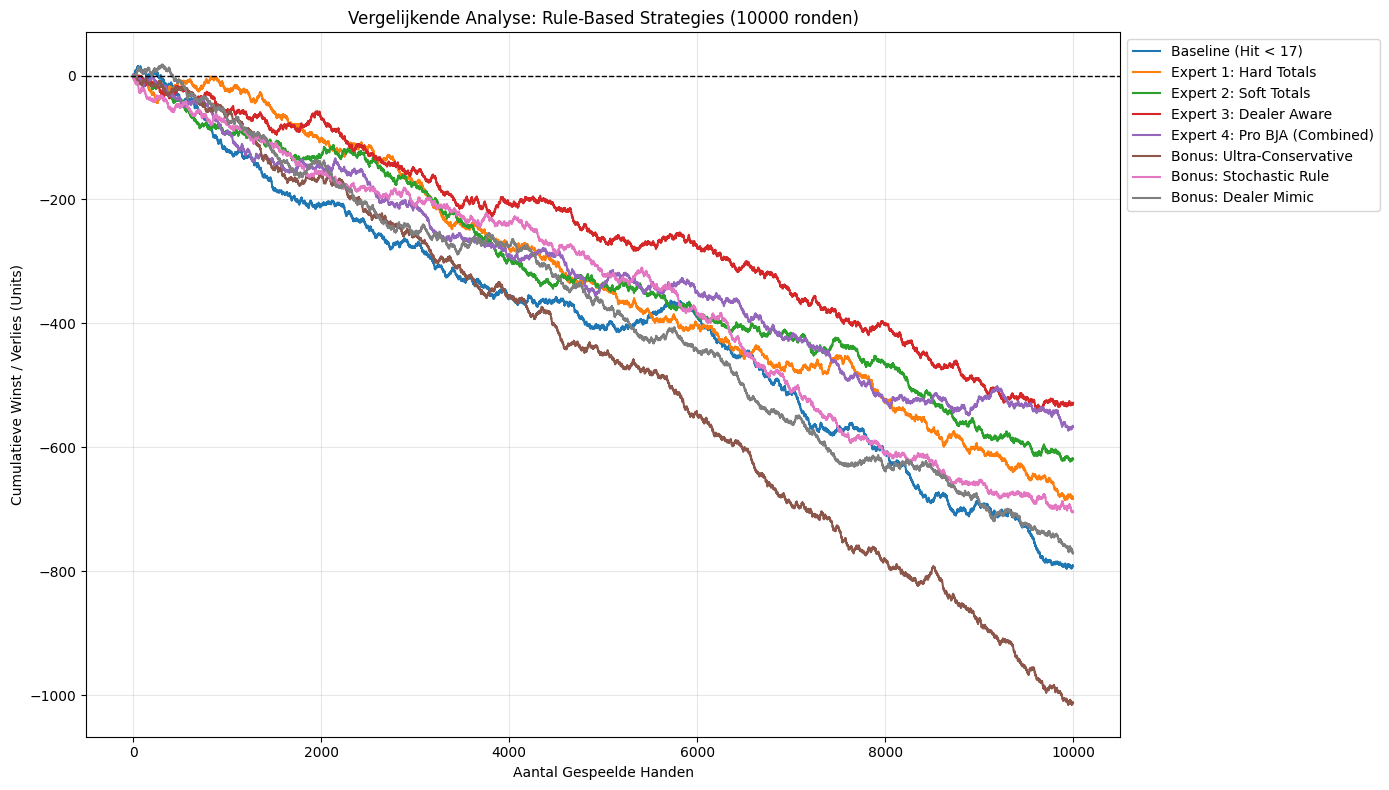

In [15]:
#Configuratie 
ROUNDS = 10000 
RESULTS_DIR = "results"

# Zorg dat de resultatenmap bestaat
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

# Lijst met Agents voor de Legende (EXACT de volgorde van de voorbeeldfoto) ---
agents_to_test = [
    (baseline_policy, "Baseline (Hit < 17)"),
    (hard_total_policy, "Expert 1: Hard Totals"),
    (soft_total_policy, "Expert 2: Soft Totals"),
    (dealer_aware_policy, "Expert 3: Dealer Aware"),
    (bja_policy, "Expert 4: Pro BJA (Combined)"),
    (safe_play_policy, "Bonus: Ultra-Conservative"), 
    (probabilistic_policy, "Bonus: Stochastic Rule"),
    (dealer_copy_policy, "Bonus: Dealer Mimic")
]

all_stats = []
# Forceer de grootte van de grafiek
plt.figure(figsize=(14, 8))

print(f"\n Simulatie gestart: {ROUNDS} rondes per agent...\n")

for policy, name in agents_to_test:
    print(f"Systeem test: {name}...")
    res = run_simulation(policy, name, ROUNDS)
    
    all_stats.append({
        "Agent": res["name"],
        "Total Profit": res["total_profit"],
        "Win Rate": res["win_rate"],
        "EV": res["avg_reward"]
    })
    
    plt.plot(res["history"], label=res["name"])


# Sla de tabel op
df = pd.DataFrame(all_stats)
print("\n--- PERFORMANCE RESULTATEN ---")
print(df.to_string(index=False))

df.to_csv(os.path.join(RESULTS_DIR, "performance_results.csv"), index=False)

# De Grafiek Configuratie (Naspelen van je voorbeeldfoto) 
plt.title(f"Vergelijkende Analyse: Rule-Based Strategies ({ROUNDS} ronden)")
plt.xlabel("Aantal Gespeelde Handen")
plt.ylabel("Cumulatieve Winst / Verlies (Units)")

# Voeg de zwarte nullijn toe
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Legende configureren (rechts, buiten de grafiek, zoals op de foto)
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# Raster aanzetten
plt.grid(True, alpha=0.3)

# Zorg dat de legende niet wordt afgesneden
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "blackjack_comparison_plot.png")
plt.savefig(plot_path)

print(f"\n Resultaten en de grafiek zijn bijgewerkt in de map '{RESULTS_DIR}'.")